In [5]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow import keras
from tensorflow.keras import layers

if tf.config.list_physical_devices('GPU'):
    tf.config.set_visible_devices([], 'GPU')
    print("GPU is enabled")
if tf.config.list_physical_devices('MPS'):
    tf.config.experimental.set_memory_growth(tf.config.list_physical_devices('MPS')[0], True)
    print("MPS is enabled")


GPU is enabled


## Slide 2: Lớp Convolutional (CNN – Conv2D)

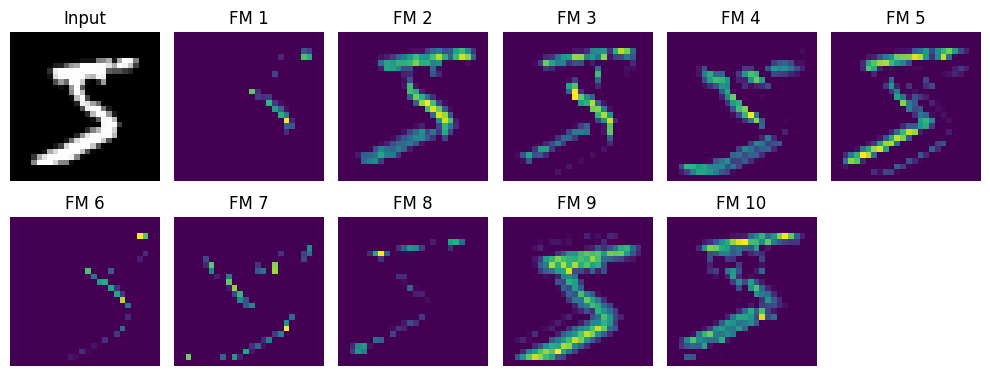

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()

# Lấy một ảnh đầu tiên từ MNIST và reshape thành (28, 28, 1)
sample_img = x_train[0].reshape(1, 28, 28, 1).astype("float32") / 255.0

# Tạo 1 Conv2D layer
conv_layer = tf.keras.layers.Conv2D(32, (3, 3), activation="relu")

# Áp dụng conv layer lên ảnh
feature_maps = conv_layer(sample_img)

# Hiển thị ảnh gốc và một vài feature map
plt.figure(figsize=(10, 4))

# Ảnh gốc
plt.subplot(2, 6, 1)
plt.imshow(sample_img[0, :, :, 0], cmap="gray")
plt.title("Input")
plt.axis("off")

# Hiển thị 10 feature maps đầu tiên
for i in range(10):
    plt.subplot(2, 6, i+2)
    plt.imshow(feature_maps[0, :, :, i], cmap="viridis")
    plt.title(f"FM {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()


## Slide 3: Lớp Pooling (MaxPooling)


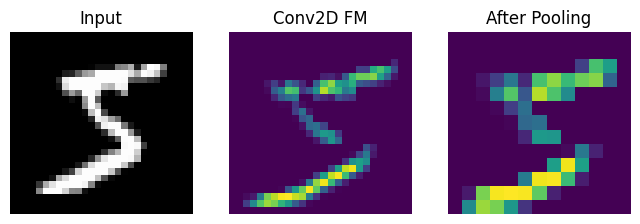

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load MNIST và lấy 1 ảnh đầu tiên
(x_train, _), _ = tf.keras.datasets.mnist.load_data()
sample_img = x_train[0].reshape(1, 28, 28, 1).astype("float32") / 255.0

# Conv layer để tạo feature maps
conv_layer = tf.keras.layers.Conv2D(8, (3, 3), activation="relu")
feature_maps = conv_layer(sample_img)

# MaxPooling 2x2
pool_layer = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))
pooled_maps = pool_layer(feature_maps)

# Hiển thị ảnh gốc, 1 feature map và feature map sau pooling
plt.figure(figsize=(8,3))

plt.subplot(1,3,1)
plt.imshow(sample_img[0,:,:,0], cmap="gray")
plt.title("Input")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(feature_maps[0,:,:,0], cmap="viridis")
plt.title("Conv2D FM")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pooled_maps[0,:,:,0], cmap="viridis")
plt.title("After Pooling")
plt.axis("off")

plt.show()


## Slide 4: Lớp Dropout


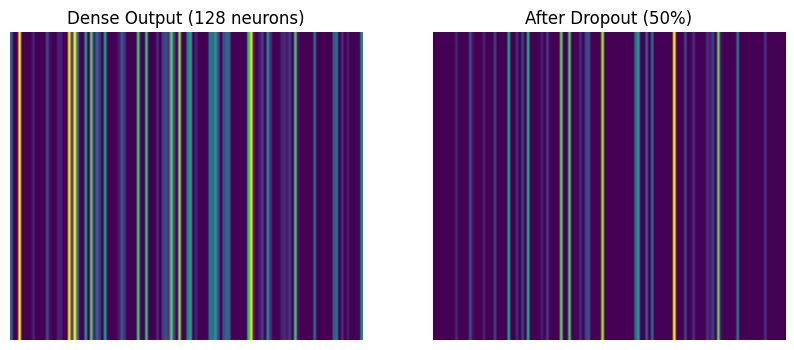

In [5]:
import numpy as np

# Flatten ảnh MNIST
flat_img = sample_img.reshape(1, -1)

# Dense + Dropout
dense_layer = tf.keras.layers.Dense(128, activation="relu")
dropout_layer = tf.keras.layers.Dropout(0.5)

h = dense_layer(flat_img)
h_drop = dropout_layer(h, training=True)

# Vẽ vector trước và sau dropout
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(h.numpy(), aspect="auto", cmap="viridis")
plt.title("Dense Output (128 neurons)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(h_drop.numpy(), aspect="auto", cmap="viridis")
plt.title("After Dropout (50%)")
plt.axis("off")

plt.show()


In [6]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [3]:

inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(inputs) 
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x) 
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x) 
x = layers.Flatten()(x)
outputs = layers.Dense(10, activation="softmax")(x) 
model = keras.Model(inputs=inputs, outputs=outputs)

In [4]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 3, 3, 128)         73856 

In [5]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data() 
train_images = train_images.reshape((60000, 28, 28, 1))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28, 28, 1))
test_images = test_images.astype("float32") / 255 
model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",               metrics=["accuracy"])
model.fit(train_images, train_labels, epochs=5, batch_size=64)

Epoch 1/5
938/938 [==============================] - 11s 11ms/step - loss: 0.1563 - accuracy: 0.9517
Epoch 2/5
938/938 [==============================] - 13s 14ms/step - loss: 0.0444 - accuracy: 0.9863
Epoch 3/5
938/938 [==============================] - 14s 15ms/step - loss: 0.0315 - accuracy: 0.9905
Epoch 4/5
938/938 [==============================] - 13s 14ms/step - loss: 0.0232 - accuracy: 0.9930
Epoch 5/5
938/938 [==============================] - 12s 13ms/step - loss: 0.0187 - accuracy: 0.9944


In [6]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

313/313 [==============================] - 1s 2ms/step - loss: 0.0321 - accuracy: 0.9908


## Slide 6: Case study – Cats vs Dogs (baseline)

In [7]:
import os, shutil, pathlib
original_dir = pathlib.Path("train")
new_base_dir = pathlib.Path("cats_vs_dogs_small")
def make_subset(subset_name, start_index, end_index):
    for category in ("cat", "dog"):
        dir = new_base_dir / subset_name / category
        os.makedirs(dir)
        fnames = [f"{i}.jpg" for i in range(start_index, end_index)]
        for fname in fnames:
            shutil.copyfile(src=original_dir / category / fname, dst=dir / f"{category}.{fname}")
make_subset("train", start_index=0, end_index=1000)
make_subset("validation", start_index=1000, end_index=1500)
make_subset("test", start_index=1500, end_index=2500)

FileExistsError: [Errno 17] File exists: 'cats_vs_dogs_small/train/cat'

In [8]:
from tensorflow import keras
from tensorflow.keras import layers
inputs = keras.Input(shape=(180, 180, 3))
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

In [9]:
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 180, 180, 3)]     0         
                                                                 
 rescaling (Rescaling)       (None, 180, 180, 3)       0         
                                                                 
 conv2d_3 (Conv2D)           (None, 178, 178, 32)      896       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 89, 89, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 87, 87, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 43, 43, 64)        0         
 g2D)                                                      

In [10]:
model.compile(loss="binary_crossentropy",optimizer="rmsprop",metrics=["accuracy"])

In [21]:
from PIL import Image
import os

data_dir = "cats_vs_dogs_small/train/dog" # Thay đổi thành đường dẫn của bạn

for subdir, dirs, files in os.walk(data_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif')):
            file_path = os.path.join(subdir, file)
            try:
                with Image.open(file_path) as img:
                    img.verify() # Kiểm tra tính toàn vẹn của tệp ảnh
            except (IOError, OSError) as e:
                print(f"Lỗi: Tệp ảnh bị hỏng hoặc rỗng tại: {file_path}. Lỗi: {e}")

In [8]:
from tensorflow.keras.utils import image_dataset_from_directory
train_dataset = image_dataset_from_directory(
    new_base_dir / "train",
    image_size=(180, 180),
    batch_size=32)
validation_dataset = image_dataset_from_directory(
    new_base_dir / "validation",
    image_size=(180, 180),
    batch_size=32)

test_dataset = image_dataset_from_directory(
    new_base_dir / "test",
    image_size=(180, 180),
    batch_size=32)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


In [23]:
for data_batch, labels_batch in train_dataset:
    print("data batch shape:", data_batch.shape)
    print("labels batch shape:", labels_batch.shape)
    break

data batch shape: (32, 180, 180, 3)
labels batch shape: (32,)


In [24]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch.keras",
        save_best_only=True,
        monitor="val_loss")
]

In [ ]:
history = model.fit(
    train_dataset,
    epochs=2,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/30
63/63 [==============================] - ETA: 0s - loss: 0.7148 - accuracy: 0.5700

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9


63/63 [==============================] - 41s 644ms/step - loss: 0.7148 - accuracy: 0.5700 - val_loss: 0.7067 - val_accuracy: 0.5600
Epoch 2/30
63/63 [==============================] - ETA: 0s - loss: 0.6777 - accuracy: 0.6180

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9


63/63 [==============================] - 44s 694ms/step - loss: 0.6777 - accuracy: 0.6180 - val_loss: 0.6382 - val_accuracy: 0.6350
Epoch 3/30
63/63 [==============================] - ETA: 0s - loss: 0.6265 - accuracy: 0.6580

...

63/63 [==============================] - 45s 719ms/step - loss: 0.0607 - accuracy: 0.9855 - val_loss: 2.7765 - val_accuracy: 0.7220
Epoch 29/30
63/63 [==============================] - ETA: 0s - loss: 0.0389 - accuracy: 0.9895

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9


63/63 [==============================] - 46s 726ms/step - loss: 0.0389 - accuracy: 0.9895 - val_loss: 2.3628 - val_accuracy: 0.7170
Epoch 30/30
63/63 [==============================] - ETA: 0s - loss: 0.0503 - accuracy: 0.9860

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9


63/63 [==============================] - 46s 732ms/step - loss: 0.0503 - accuracy: 0.9860 - val_loss: 2.2372 - val_accuracy: 0.7350


In [1]:
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

Doan Code tren co accuracy rat thap do bi overfit.

## Data augmentation

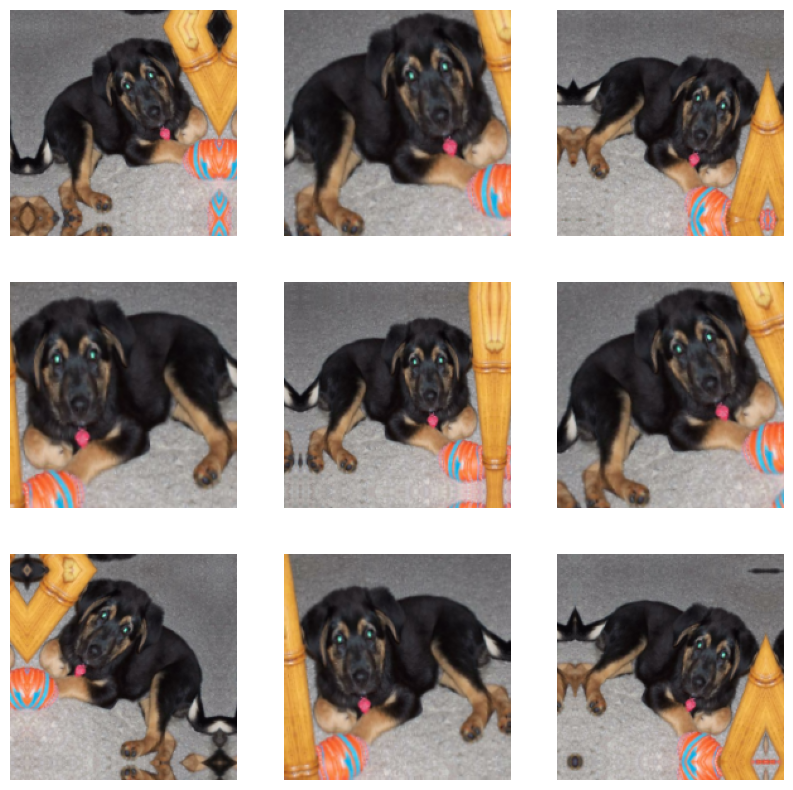

In [9]:
data_augmentation = keras.Sequential(
[
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
]
)

plt.figure(figsize=(10, 10))
for images, _ in train_dataset.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.axis("off")

In [10]:
inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)
model.compile(loss="binary_crossentropy",
optimizer="rmsprop",
metrics=["accuracy"])

In [12]:
callbacks = [
keras.callbacks.ModelCheckpoint(
filepath="convnet_from_scratch_with_augmentation.keras",
save_best_only=True,
monitor="val_loss")
]
history = model.fit(
train_dataset,
epochs=10,
validation_data=validation_dataset,
callbacks=callbacks)

Epoch 1/10
63/63 [==============================] - ETA: 0s - loss: 0.7105 - accuracy: 0.5145

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9


63/63 [==============================] - 44s 701ms/step - loss: 0.7105 - accuracy: 0.5145 - val_loss: 0.6892 - val_accuracy: 0.5410
Epoch 2/10
63/63 [==============================] - ETA: 0s - loss: 0.7184 - accuracy: 0.5340

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9


63/63 [==============================] - 46s 727ms/step - loss: 0.7184 - accuracy: 0.5340 - val_loss: 0.6866 - val_accuracy: 0.5120
Epoch 3/10
63/63 [==============================] - ETA: 0s - loss: 0.7082 - accuracy: 0.5805

...

63/63 [==============================] - 53s 834ms/step - loss: 0.5944 - accuracy: 0.6835 - val_loss: 0.6067 - val_accuracy: 0.6830
Epoch 9/10
63/63 [==============================] - ETA: 0s - loss: 0.5791 - accuracy: 0.6945

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9


63/63 [==============================] - 44s 702ms/step - loss: 0.5791 - accuracy: 0.6945 - val_loss: 0.5633 - val_accuracy: 0.7050
Epoch 10/10
63/63 [==============================] - ETA: 0s - loss: 0.5661 - accuracy: 0.7100

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9


63/63 [==============================] - 42s 662ms/step - loss: 0.5661 - accuracy: 0.7100 - val_loss: 0.5606 - val_accuracy: 0.7000


In [ ]:
test_model = keras.models.load_model(
"convnet_from_scratch_with_augmentation.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")